(np.float64(-11.7373170623862),
 np.float64(7.272829086564677),
 np.float64(-9.970860628000821),
 np.float64(12.743677162116505))

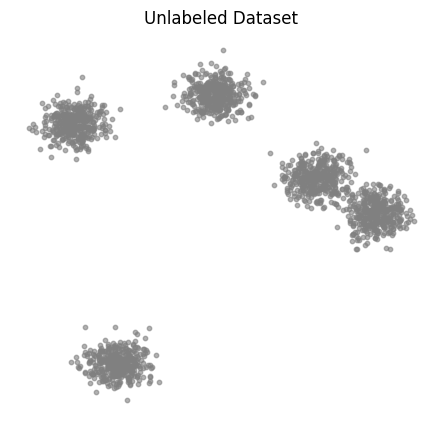

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y_true = make_blobs(n_samples=2000, centers=5, cluster_std=0.7, random_state=42)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', s=10, alpha=0.6)
plt.title("Unlabeled Dataset")
plt.axis('off')

In [3]:
k = 5
kmeans = KMeans(n_clusters=k)
y_pred = kmeans.fit_predict(X)

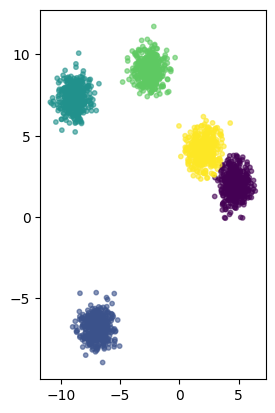

In [4]:
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=10, alpha=0.6)

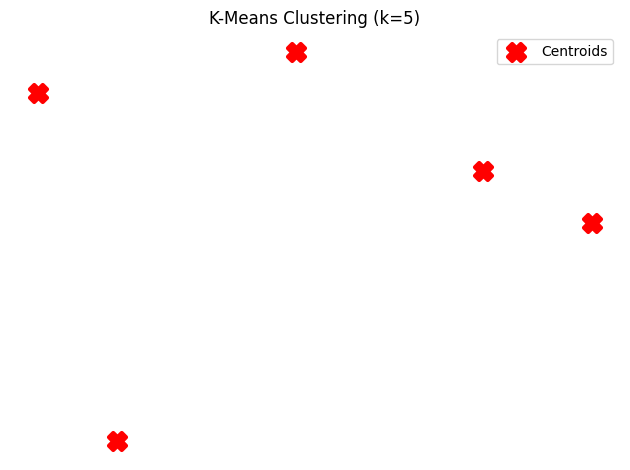

Cluster Centers:
 [[ 4.7182956   2.02476404]
 [-6.91459562 -6.82220969]
 [-8.85721659  7.3281411 ]
 [-2.53116173  9.01582781]
 [ 2.04588928  4.13924851]]


In [5]:
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=150, marker='X', linewidths=3, label='Centroids')

plt.title(f"K-Means Clustering (k={k})")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

print("Cluster Centers:\n", centers)

In [7]:
y_pred

array([4, 3, 0, ..., 1, 0, 4], shape=(2000,), dtype=int32)

In [8]:
y_pred is kmeans.labels_

True

In [10]:
import numpy as np
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([4, 0, 4, 4], dtype=int32)

In [11]:
kmeans.transform(X_new)

array([[ 4.71836059, 11.20905957, 10.33631333,  7.4584596 ,  2.96007553],
       [ 1.71847404, 13.27142005, 12.99933355,  8.93395713,  2.34237303],
       [ 7.77966401, 10.57354539,  7.28284227,  6.0340694 ,  5.17289917],
       [ 7.73291253, 10.11076913,  7.59064771,  6.53267337,  5.30548153]])

In [12]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)

In [14]:
kmeans.fit(X)

print("Inertia:", kmeans.inertia_)

Inertia: 12630.93593960227


In [15]:
kmeans.score(X)

-12630.93593960227

In [16]:
from sklearn.cluster import MiniBatchKMeans
minibatch_kmeans = MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


In [17]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

0.6178435956745626

In [1]:
import os
from matplotlib.image import imread
import urllib.request

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/images/unsupervised_learning/ladybug.png"
urllib.request.urlretrieve(url, "ladybug.png")

image = imread("ladybug.png")
print("Original image shape:", image.shape)


Original image shape: (533, 800, 3)


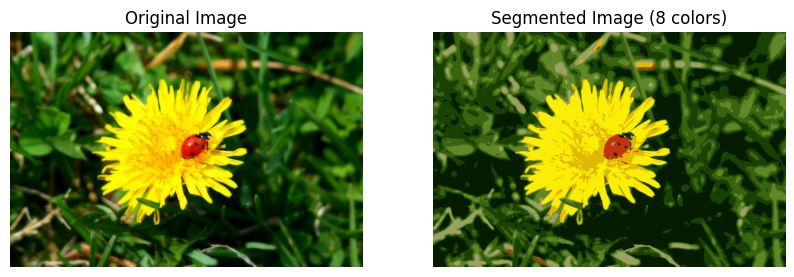

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = image.reshape(-1, 3)

k = 8
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)

segmented_img = kmeans.cluster_centers_[kmeans.labels_]

segmented_img = segmented_img.reshape(image.shape)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Segmented Image ({k} colors)")
plt.imshow(segmented_img)
plt.axis('off')

plt.show()

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, random_state=42)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

print("Baseline Accuracy:", log_reg.score(X_test, y_test))

Baseline Accuracy: 0.9733333333333334


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50, random_state=42)),
    ("scaler", StandardScaler()),  
    ("log_reg", LogisticRegression(max_iter=5000, random_state=42))
])

pipeline.fit(X_train, y_train)
print("Pipeline Accuracy (Scaled):", pipeline.score(X_test, y_test))

Pipeline Accuracy (Scaled): 0.9711111111111111


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("kmeans", KMeans(random_state=42)),
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = dict(kmeans__n_clusters=range(50, 100, 10))

grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

print("Best k found:", grid_clf.best_params_)
print("Best Accuracy:", grid_clf.score(X_test, y_test))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ..............................kmeans__n_clusters=50; total time=   0.1s
[CV] END ..............................kmeans__n_clusters=50; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=50; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=60; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=60; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=60; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=70; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=70; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=70; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=80; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=80; total time=   0.3s
[CV] END ..............................kmeans__n_

In [14]:
import numpy as np

k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

representative_digit_idx = np.argmin(X_digits_dist, axis=0)

X_representative_digits = X_train[representative_digit_idx]

In [16]:
y_representative_digits = y_train[representative_digit_idx]

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_representative_digits, y_representative_digits)

print("Accuracy (50 representative samples):", log_reg.score(X_test, y_test))

Accuracy (50 representative samples): 0.9133333333333333


In [18]:
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

log_reg_prop = LogisticRegression(max_iter=5000, random_state=42)
log_reg_prop.fit(X_train, y_train_propagated)
print("Accuracy (Fully Propagated):", log_reg_prop.score(X_test, y_test))

Accuracy (Fully Propagated): 0.92


In [19]:
percentile_closest = 20
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]

for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]